In [3]:
import numpy as np                  # to do math
from astropy.io import fits         # handline .fits files
import pandas as pd                 # table format
import os                           # universal os
from astroquery.sdss import SDSS    # to query SDSS spectra
import matplotlib.pyplot as plt     # for plotting
from scipy.ndimage import median_filter
from astropy.stats import mad_std

## Load in high ionization subsample

In [6]:
filename = 'high_ionization_eBOSS.csv'            # give the dataframe a name
path = os.path.join('..','subsamples', filename)  # path to dataframe

high_ion_eBOSS = pd.read_csv(path)
high_ion_eBOSS

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR
0,3590,55201,554,03590-55201-0554,0.344603,0.000014,11.001109,0.790189,632.75665,129.946550,3.753939,51.275000,74.241040,2.097736
1,3662,55182,546,03662-55182-0546,0.205231,0.000013,112.402841,37.085000,424.49023,155.580230,2.809634,39.868034,20.860123,1.420017
2,3663,55176,766,03663-55176-0766,0.076291,0.000011,114.085117,45.979487,582.44140,120.043915,3.159346,75.502990,46.597088,2.879046
3,3667,55186,806,03667-55186-0806,0.421750,0.000011,115.844578,37.422689,701.57510,106.982895,1.809964,64.058450,47.220814,1.560171
4,3670,55480,196,03670-55480-0196,0.068112,0.000010,117.144778,38.750600,728.61720,138.177730,1.710456,78.052820,43.722090,2.022613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,11650,58508,660,11650-58508-0660,0.286031,0.000012,27.032297,6.145396,511.85080,156.112440,0.336438,57.880306,40.156470,0.156007
1382,11651,58511,742,11651-58511-0742,0.370853,0.000012,127.252482,35.968856,2130.91260,186.924150,2.661142,57.401127,39.863186,1.415901
1383,11678,58511,672,11678-58511-0672,0.044301,0.000009,136.496076,26.971381,689.83390,131.420930,1.519092,55.188960,44.326310,1.329630
1384,11678,58511,785,11678-58511-0785,0.561287,0.000012,136.935390,27.037606,156.22488,102.122080,2.903220,24.458094,47.877926,1.466753


# Subsample of galaxies with He II bump

... still working on this next step ...

Select galaxies in this high-ionization subsample that have strong He II 4686 emission. This is a key characteristic in VMS spectra.

In [7]:
He_II_mask = (

    # high ionization
    (high_ion_eBOSS['PLATE'] == '11288')    # ~~~~ experiment with equivalent width values for He II ~~~~ ? for 1 ~~
    & (high_ion_eBOSS['MJD'] == '58401') # could try SNR of 1
    & (high_ion_eBOSS['FIBER'] == '0011')
)

initial_VMS_eBOSS = high_ion_eBOSS[He_II_mask]
num_filtered = len(initial_VMS_eBOSS)
num_filtered  # let's see the size of this new sample

0

In [8]:
He_II_mask = (

    # # high ionization
    (high_ion_eBOSS['HEII_4686_EW'] > 10) &    # ~~~~ experiment with equivalent width values for He II ~~~~ ? for 1 ~~
    (high_ion_eBOSS['HEII_4686_SNR'] >= 2)  # could try SNR of 1
)

initial_VMS_eBOSS = high_ion_eBOSS[He_II_mask]
num_filtered = len(initial_VMS_eBOSS)
num_filtered  # let's see the size of this new sample

27

In [6]:
initial_VMS_eBOSS

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR
0,3590,55201,554,03590-55201-0554,0.344603,0.000014,11.001109,0.790189,632.75665,129.946550,3.753939,51.275000,74.241040,2.097736
2,3663,55176,766,03663-55176-0766,0.076291,0.000011,114.085117,45.979487,582.44140,120.043915,3.159346,75.502990,46.597088,2.879046
4,3670,55480,196,03670-55480-0196,0.068112,0.000010,117.144778,38.750600,728.61720,138.177730,1.710456,78.052820,43.722090,2.022613
5,3684,55246,926,03684-55246-0926,0.374749,0.000012,121.873025,49.402435,870.59960,169.095780,3.052166,60.386830,55.684390,2.296688
7,3694,55209,754,03694-55209-0754,0.214910,0.000013,126.156897,51.000110,968.84766,150.431290,0.881623,48.384785,50.552837,2.175619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,11351,58440,771,11351-58440-0771,0.453628,0.000012,154.278941,29.371084,1091.45650,159.676650,3.122645,73.294075,57.108276,2.794029
1366,11376,58430,514,11376-58430-0514,0.355478,0.000014,139.657260,31.460019,1068.50790,167.113880,8.275560,82.553510,45.941936,2.816112
1369,11380,58462,758,11380-58462-0758,0.051409,0.000013,150.587336,31.492619,1073.15870,227.006770,5.325217,52.614304,51.429700,7.266611
1374,11397,58522,384,11397-58522-0384,0.227541,0.000010,190.490955,30.173515,650.48330,126.574070,3.147368,58.875340,45.063488,3.486196


In [7]:
# # find example VMS and WR galaxies Christy gave
# VMS_PMF = ..
# WR_PMF = ..



In [9]:
def column_sep(num_filtered, table):
    
    rest_frame_wavelengths = []
    rest_frame_flux_densities = []
    rest_frame_flux_density_errs = []
    fail = []

    for i in range(num_filtered):
        
        # saving basic info for this galaxy
        data = table.iloc[i]
        plate = int(data['PLATE'])
        mjd   = int(data['MJD'])
        fiber = int(data['FIBER'])
        key = data['PMF_STRING']
        z = data['Z']
        print(i)

        # try to query spectra from SDSS archive
        try:
            # query
            spec = SDSS.get_spectra(plate=plate,mjd=mjd,fiberID=fiber, cache=False)
            
            if spec is not None:
                hdu = spec[0]  # header-data unit (hdu)
                
                # ----------- saving spectral data ------------
    
                # flux
                flux_density_factor = hdu[1].data['flux']             # 10^-17 * [ergs / s / cm^2 / A]
                flux_density = 10**(-17) * flux_density_factor        # [ergs / s / cm^2 / A]
                rest_flux_density = flux_density * (1+z)              # convert spectrum from observed frame to rest frame using the object's redshift
                rest_frame_flux_densities.append(rest_flux_density)   # ... saving these data
    
                # flux error
                ivar = hdu[1].data['ivar']
                flux_density_err = np.zeros_like(flux_density)
                good = ivar > 0                                             # avoid dividing by zero
                flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])
                rest_flux_density_err = flux_density_err * (1+z)            # convert spectrum from observed frame to rest frame using the object's redshift
                rest_frame_flux_density_errs.append(rest_flux_density_err)  # ... saving these data
    
                # wavelength
                log_wav = hdu[1].data['loglam']
                wavelength = 10**log_wav                         # [A]
                rest_wavelength = wavelength / (1+z)             # convert spectrum from observed frame to rest frame using the object's redshift
                rest_frame_wavelengths.append(rest_wavelength)   # ... saving these data
                # ----------------------------------------------
    
                print(f'successfully saved spectrum for {key}')

            else: 
                print('test of fail drop working')
                fail.append(i)
                # initial_VMS_eBOSS.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully queryS
                
                # if unable to find spectra, give exception
        except Exception as e:
            print(f"Failed to retrieve spectrum for {key}: {e}")
            # initial_VMS_eBOSS.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully query
        
    print(f'\nquery complete for {num_filtered} galaxies')
    
    fail_np = np.array(fail)
    for i in fail_np:
        initial_VMS_eBOSS.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully queryS
    
    return rest_frame_wavelengths, rest_frame_flux_densities, rest_frame_flux_density_errs


In [10]:
rest_frame_wavelengths, rest_frame_flux_densities, rest_frame_flux_density_errs = column_sep(num_filtered, initial_VMS_eBOSS)

0
successfully saved spectrum for 04387-55534-0806
1
successfully saved spectrum for 05129-55864-0926
2
successfully saved spectrum for 06514-56487-0217
3
successfully saved spectrum for 06641-56383-0398
4
successfully saved spectrum for 06670-56389-0169
5
successfully saved spectrum for 06748-56371-0803
6
successfully saved spectrum for 06754-56414-0984
7
successfully saved spectrum for 06931-56388-0077
8
successfully saved spectrum for 07155-56629-0872
9
successfully saved spectrum for 07242-56628-0181
10
successfully saved spectrum for 07303-57013-0321
11
successfully saved spectrum for 07666-57339-0993
12
successfully saved spectrum for 07733-58103-0219
13
successfully saved spectrum for 07741-58078-0996
14
successfully saved spectrum for 08213-58193-0670
15
successfully saved spectrum for 08409-57867-0375
16
successfully saved spectrum for 08513-57842-0898
17
successfully saved spectrum for 08955-57451-0671
18
successfully saved spectrum for 09149-58039-0721
19
successfully saved 

In [13]:
num_filtered = len(initial_VMS_eBOSS) 
num_filtered   # should have 461 rows ...

27

Note: Remove galaxy with no info

In [15]:
#~~~~~~~~~~~~~~~~~~~~~ My addition ~~~~~~~~~~~~~~~~~~~~~~

def sectioner(x1, x2, rest_frame_wavelengths, rest_frame_flux_densities):
    '''Separates each section of spectra between two wavelengths

    x1 = shorter wavelength
    x2 = longer wavelength 
    '''
    boolean_array = []
    median_flux_array = []
    median_wavelength_array = []
    
    for i in range(len(rest_frame_wavelengths)):       #num_filtered):
        section = (rest_frame_wavelengths[i] > x1) & (rest_frame_wavelengths[i] < x2)
        boolean_array.append(section)

        flux_density = rest_frame_flux_densities[i][section]
        waves = rest_frame_wavelengths[i][section]
        median = np.mean(flux_density)
        median_idx = np.argmin(np.abs(flux_density - median))
        median_wave = waves[median_idx]
        
        median_flux_array.append(median)
        median_wavelength_array.append(median_wave)

    print('Sectioning Finished')
    return boolean_array, median_flux_array, median_wavelength_array

In [16]:
right_flat, right_median, right_median_wav = sectioner(4560, 4600, rest_frame_wavelengths, rest_frame_flux_densities)
left_flat, left_median, left_median_wav = sectioner(4755, 4795, rest_frame_wavelengths, rest_frame_flux_densities)
HeII_bump, bump_median, bump_median_wav = sectioner(4665, 4702, rest_frame_wavelengths, rest_frame_flux_densities)
between, blank, blank = sectioner(4500, 4850, rest_frame_wavelengths, rest_frame_flux_densities)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished


using HeII 4686 bump EW measurement to performe another cut to our sample

In [17]:
# # #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of HeII bump EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# a = 0
# c = 25
# # c = num_filtered - 1
# kay = np.linspace(a, c, ((c-a)+1), dtype=int)

# # kay = [50]

# k = np.array(kay)

# #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# for i in k:            
    
#     x = rest_frame_wavelengths[i] ######POTENTIAL TO CHAN
#     y = rest_frame_flux_densities[i]
#     # outside_bump, outside_median, outside_median_wav = sectioner(ranging[0], ranging[1], rest_frame_wavelengths, rest_frame_flux_densities)
    
#     ## Median Smooth spectra[po
#     ############ Creating axes #################
#     highlighted = right_flat[i] | left_flat[i] # "Flat" continuum portions
    
#     yblue = rest_frame_flux_densities[i].copy()
#     yblue[~highlighted] = np.nan
    
#     ybump = rest_frame_flux_densities[i].copy()
#     ybump[~HeII_bump[i]] = np.nan

#     # out_bump = rest_frame_flux_densities[i].copy()
#     # out_bump[~outside_bump[i]] = np.nan
 
#     yspectra = rest_frame_flux_densities[i].copy()
#     yspectra[~between[i]] = np.nan

#     # baseline = equation.copy()
#     baseline = linear_func(x).copy()
#     baseline[~between[i]] = np.nan

#     plt.figure(figsize=(15,6))

#     ############### Plotting ###################
#     plt.plot(x, yspectra, color='black')
#     plt.plot(x, yblue)
#     plt.plot(x, ybump, color='red')
#     plt.plot(x, baseline, color='orange')
#     # plt.plot(x, out_bump, color ='green')
#     plt.scatter(x_points, y_points, color='green')

#     plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
#     plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')

#     #yscale = log
#     # plt.yscale('log')
#     median_flux = np.median(rest_frame_flux_densities[i])
#     lower_y_lim = median_flux * 0.005
#     upper_y_lim = median_flux * 5
#     # plt.ylim(lower_y_lim, upper_y_lim)
#     plt.tight_layout() 
#     plt.show()


In [18]:
HeII4686_bump_EWs = []

for i in range(len(rest_frame_wavelengths)):
    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x = rest_frame_wavelengths[i]
    y = rest_frame_flux_densities[i]
    
    ### Measuring difference between bump flux and baseline equation flux 
    bump_wav = rest_frame_wavelengths[i][HeII_bump[i]]
    bump_flux = rest_frame_flux_densities[i][HeII_bump[i]]
    baseline_flux = linear_func(x)[HeII_bump[i]]
    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width
    EW = np.trapezoid(norm_delta_flux, bump_wav)      
    HeII4686_bump_EWs.append(EW)

print('success')

success


In [19]:
HeII4686_bump_EWs

initial_VMS_eBOSS['HeII_4686_BUMP_EW'] = HeII4686_bump_EWs
initial_VMS_eBOSS

He_II_bump_mask = (
    
    # high ionization
    (initial_VMS_eBOSS['HeII_4686_BUMP_EW'] > 5) &     # ~~~~ experiment with equivalent width values for He II ~~~~ ? for 1 ~~
    (initial_VMS_eBOSS['HeII_4686_BUMP_EW'] * initial_VMS_eBOSS['HEII_4686_SNR'] >= 1)  # replaced with SNR list because of risk of low SNR
) #is it correct that we want that ratio to be less than 2.5?

VMS_WR_eBOSS = initial_VMS_eBOSS[He_II_bump_mask].copy()
print(type(VMS_WR_eBOSS))
print(VMS_WR_eBOSS)
num_filtered_2 = len(VMS_WR_eBOSS)
num_filtered_2 # let's see the size of this new sample

<class 'pandas.core.frame.DataFrame'>
      PLATE    MJD  FIBER        PMF_STRING         Z     Z_ERR          RA  \
109    4387  55534    806  04387-55534-0806  0.185343  0.000010   36.444685   
211    5129  55864    926  05129-55864-0926  0.065961  0.000010   24.476801   
330    6514  56487    217  06514-56487-0217  0.057363  0.000009  354.308920   
337    6641  56383    398  06641-56383-0398  0.065403  0.000014  181.264749   
340    6670  56389    169  06670-56389-0169  0.460229  0.000012  189.635210   
358    6748  56371    803  06748-56371-0803  0.029031  0.000014  204.573311   
359    6754  56414    984  06754-56414-0984  0.467857  0.000042  201.436887   
392    6931  56388     77  06931-56388-0077  0.515300  0.000011  216.404388   
424    7155  56629    872  07155-56629-0872  0.183744  0.000009   13.647946   
476    7303  57013    321  07303-57013-0321  0.499442  0.000011  132.092953   
634    7666  57339    993  07666-57339-0993  0.058941  0.000013    1.000268   
682    7733  5

/var/folders/fw/1376yg8d0cd1k6pwzcrdyxx80000gn/T/ipykernel_8576/2248272521.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  initial_VMS_eBOSS['HeII_4686_BUMP_EW'] = HeII4686_bump_EWs


20

In [20]:
rest_frame_wavelengths_2, rest_frame_flux_densities_2, rest_frame_flux_density_errs_2 = column_sep(num_filtered_2, VMS_WR_eBOSS)

0
successfully saved spectrum for 04387-55534-0806
1
successfully saved spectrum for 05129-55864-0926
2
successfully saved spectrum for 06514-56487-0217
3
successfully saved spectrum for 06641-56383-0398
4
successfully saved spectrum for 06670-56389-0169
5
successfully saved spectrum for 06748-56371-0803
6
successfully saved spectrum for 06754-56414-0984
7
successfully saved spectrum for 06931-56388-0077
8
successfully saved spectrum for 07155-56629-0872
9
successfully saved spectrum for 07303-57013-0321
10
successfully saved spectrum for 07666-57339-0993
11
successfully saved spectrum for 07733-58103-0219
12
successfully saved spectrum for 07741-58078-0996
13
successfully saved spectrum for 08513-57842-0898
14
successfully saved spectrum for 08955-57451-0671
15
successfully saved spectrum for 10251-58173-0702
16
successfully saved spectrum for 10733-58244-0245
17
successfully saved spectrum for 10745-58501-0265
18
successfully saved spectrum for 11312-58433-0676
19
successfully saved 

In [21]:
VMS_WR_eBOSS.to_csv('../subsamples/VMS_WR_eBOSS.csv', index=False)

In [22]:
right_flat, right_median, right_median_wav = sectioner(4560, 4600, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
left_flat, left_median, left_median_wav = sectioner(4755, 4795, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
HeII_bump, bump_median, bump_median_wav = sectioner(4665, 4702, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
between, blank, blank = sectioner(4500, 4850, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
outside_bump, outside_median, outside_median_wav = sectioner(4600, 4755, rest_frame_wavelengths_2, rest_frame_flux_densities_2)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished


85
(4606,)


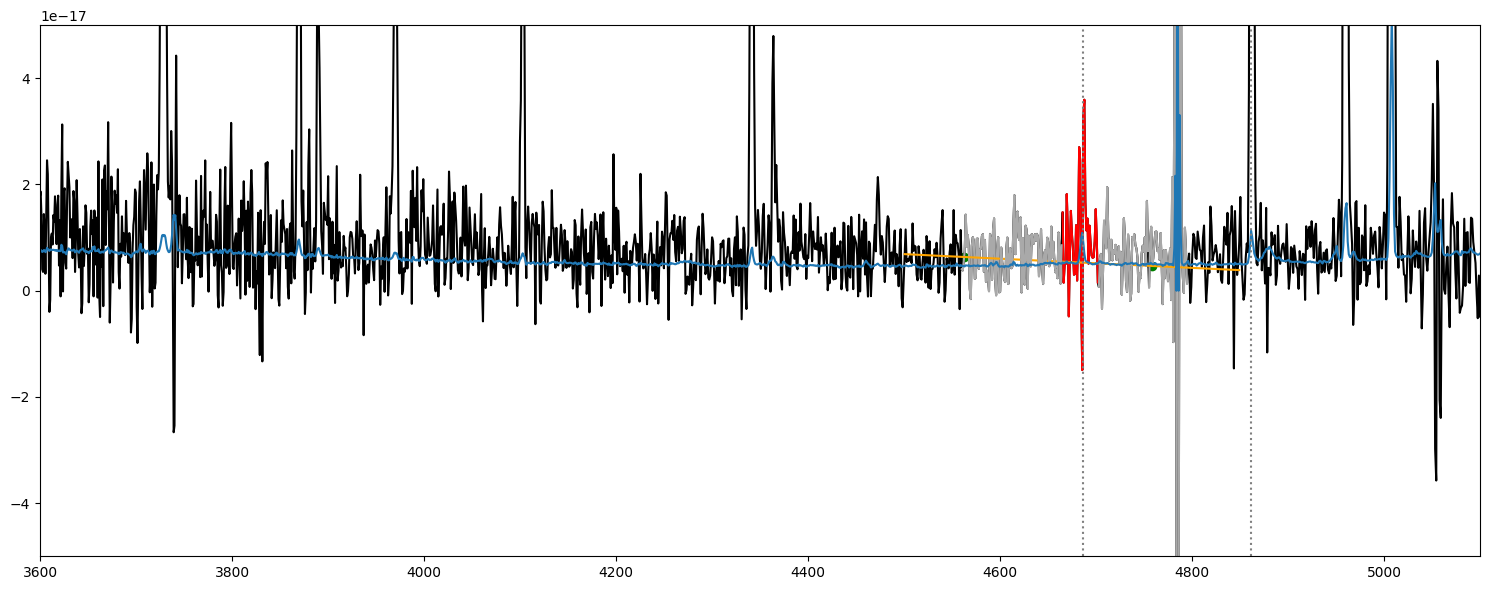

success
[array([], dtype=float64)]


In [ ]:
# compute just blue bump
wolf_rayet_bump_EWs = []
wolf_rayet_bump_EW_SNR = []

# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# a = 100
# c = 125
# # c = num_filtered - 1
# kay = np.linspace(a, c, ((c-a)+1), dtype=int)

kay = [85]

k = np.array(kay)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:    
    print(i)
    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x = rest_frame_wavelengths_2[i]
    y = rest_frame_flux_densities_2[i]

    ### Measuring difference between bump flux and baseline equation flux 
    WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
    print(np.shape(WolfRayet_bump))

    bump_wav = rest_frame_wavelengths_2[i][WolfRayet_bump[i]]
    bump_flux = rest_frame_flux_densities_2[i][WolfRayet_bump[i]]
    baseline_flux = linear_func(x)[WolfRayet_bump[i]]
    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width
    EW = np.trapezoid(norm_delta_flux, bump_wav)      
    wolf_rayet_bump_EWs.append(EW)

    ############ Creating axes #################
    highlighted = right_flat[i] | left_flat[i] # "Flat" continuum portions
    
    yblue = rest_frame_flux_densities_2[i].copy()
    yblue[~highlighted] = np.nan
    
    ybump = rest_frame_flux_densities_2[i].copy()
    ybump[~HeII_bump[i]] = np.nan

    out_bump = rest_frame_flux_densities_2[i].copy()
    WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
    out_bump[~WolfRayet_bump] = np.nan

    # --------------------
    # calcualte noise (sigma)
    # squares = rest_frame_flux_density_errs_2[i][region]**2
    # sum = np.sum(squares)
    # sigma = np.sqrt(sum)
    # SNR = WolfRayet_bump / sigma
    # save values to list !!!
    # ----------------------
 
    yspectra = rest_frame_flux_densities_2[i].copy()
    # yspectra[~between[i]] = np.nan

    # baseline = equation.copy()
    baseline = linear_func(x).copy()
    baseline[~between[i]] = np.nan

    plt.figure(figsize=(15,6))

    ############### Plotting ###################
    plt.plot(x, yspectra, color='black')
    plt.plot(x, yblue, color='darkgray')
    plt.plot(x, ybump, color='red')
    plt.plot(x, baseline, color='orange')
    plt.plot(x, out_bump, color ='darkgray')
    plt.scatter(x_points, y_points, color='green')
    plt.plot(x, rest_frame_flux_density_errs_2[i])

    plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
    plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')

    #yscale = log
    # plt.yscale('log')
    median_flux = np.median(rest_frame_flux_densities_2[i])
    # lower_y_lim = -0.025
    # upper_y_lim = 0.25
    # lower_y_lim = median_flux * 0.005
    # upper_y_lim = median_flux * 5
    plt.ylim(-0.05e-15, 0.5e-16)
    plt.xlim(3600, 5100)
    plt.tight_layout() 
    plt.show()


print('success')
print(wolf_rayet_bump_EWs)

## Full Spectrum

5


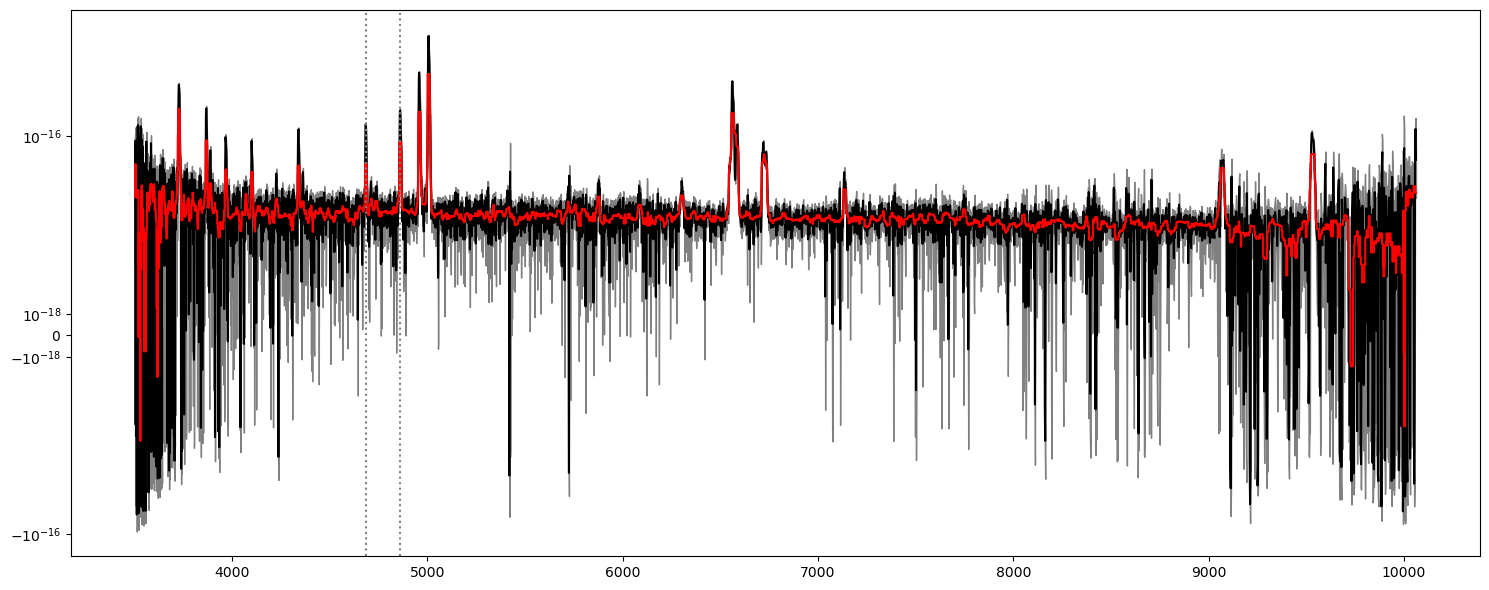

success
[]


In [ ]:
wolf_rayet_bump_EWs = []

# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# a = 100
# c = 125
# # c = num_filtered - 1
# kay = np.linspace(a, c, ((c-a)+1), dtype=int)

kay = [5]

k = np.array(kay)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:    
    print(i)
    # #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    # max_flux_median = np.max([right_median[i], left_median[i]])
    # min_flux_median = np.min([right_median[i], left_median[i]])
    
    # if max_flux_median == right_median[i]:
    #     max_wave_med = right_median_wav[i]
    #     min_wave_med = left_median_wav[i]
    # elif max_flux_median == left_median[i]: ##### learned elif = else if ######
    #     max_wave_med = left_median_wav[i]
    #     min_wave_med = right_median_wav[i]
    # else: 
    #     print('failed result:')
        
    # ########## New Method of finding base equation ###########
    # y_points = np.array([max_flux_median, min_flux_median])
    # x_points = np.array([max_wave_med, min_wave_med])
    
    # coefficients = np.polyfit(x_points, y_points, 1)
    # linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x = rest_frame_wavelengths_2[i]
    y = rest_frame_flux_densities_2[i]

    ### Measuring difference between bump flux and baseline equation flux 
    WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
    # print(np.shape(WolfRayet_bump))

    # bump_wav = rest_frame_wavelengths_2[i][WolfRayet_bump[i]]
    # bump_flux = rest_frame_flux_densities_2[i][WolfRayet_bump[i]]
    # baseline_flux = linear_func(x)[WolfRayet_bump[i]]
    # delta_bump_flux = bump_flux - baseline_flux
    # norm_delta_flux = delta_bump_flux / baseline_flux
    
    # ##### Calculating Equivalent Width
    # EW = np.trapezoid(norm_delta_flux, bump_wav)      
    # wolf_rayet_bump_EWs.append(EW)

    ############ Creating axes #################
    highlighted = right_flat[i] | left_flat[i] # "Flat" continuum portions
    
    yblue = rest_frame_flux_densities_2[i].copy()
    yblue[~highlighted] = np.nan
    
    ybump = rest_frame_flux_densities_2[i].copy()
    ybump[~HeII_bump[i]] = np.nan

    out_bump = rest_frame_flux_densities_2[i].copy()
    WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
    out_bump[~WolfRayet_bump] = np.nan
 
    yspectra = rest_frame_flux_densities_2[i].copy()
    # yspectra[~between[i]] = np.nan

    # baseline = equation.copy()
    baseline = linear_func(x).copy()
    baseline[~between[i]] = np.nan

    plt.figure(figsize=(15,6))

    linthresh = mad_std(rest_frame_flux_densities_2[i])
    median_smooth_flux = median_filter(rest_frame_flux_densities_2[i], size=15, mode='reflect')
    plt.yscale('symlog', linthresh=linthresh, linscale=1)
    
    upper_err = rest_frame_flux_densities_2[i] + rest_frame_flux_density_errs_2[i]
    lower_err = rest_frame_flux_densities_2[i] - rest_frame_flux_density_errs_2[i]


    ############### Plotting ###################
    plt.plot(x, yspectra, color='black')
    # plt.plot(x, yblue, color='darkgray')
    # plt.plot(x, ybump, color='red')
    # plt.plot(x, baseline, color='orange')
    # plt.plot(x, out_bump, color ='darkgray')
    # plt.scatter(x_points, y_points, color='green')
    plt.fill_between(x, upper_err, lower_err, color='gray')
    plt.step(x, median_smooth_flux, where='mid', color='red', label='smoothed data')

    plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
    plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')

    
    median_flux = np.median(rest_frame_flux_densities_2[i])

    # lower_y_lim = -0.025
    # upper_y_lim = 0.25
    # lower_y_lim = median_flux * 0.005
    # upper_y_lim = median_flux * 5
    # plt.ylim(-0.05e-15, 0.5e-16)
    plt.tight_layout() 
    plt.show()


print('success')
print(wolf_rayet_bump_EWs)

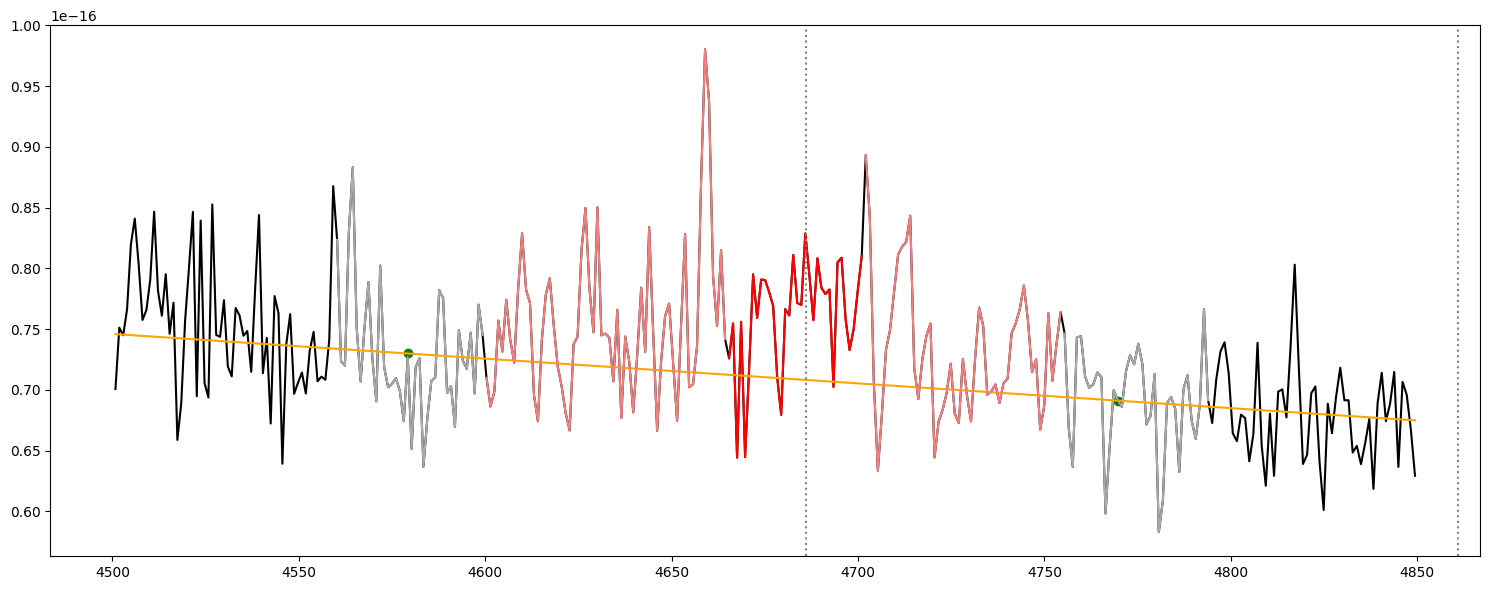

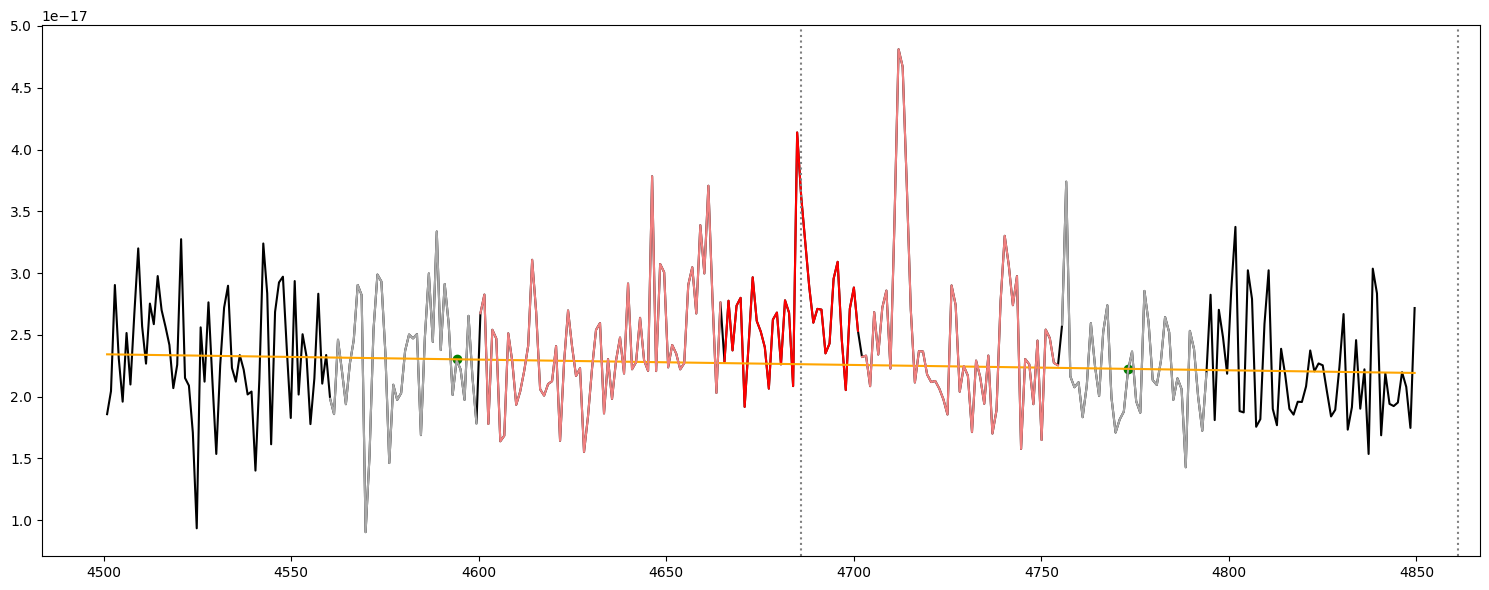

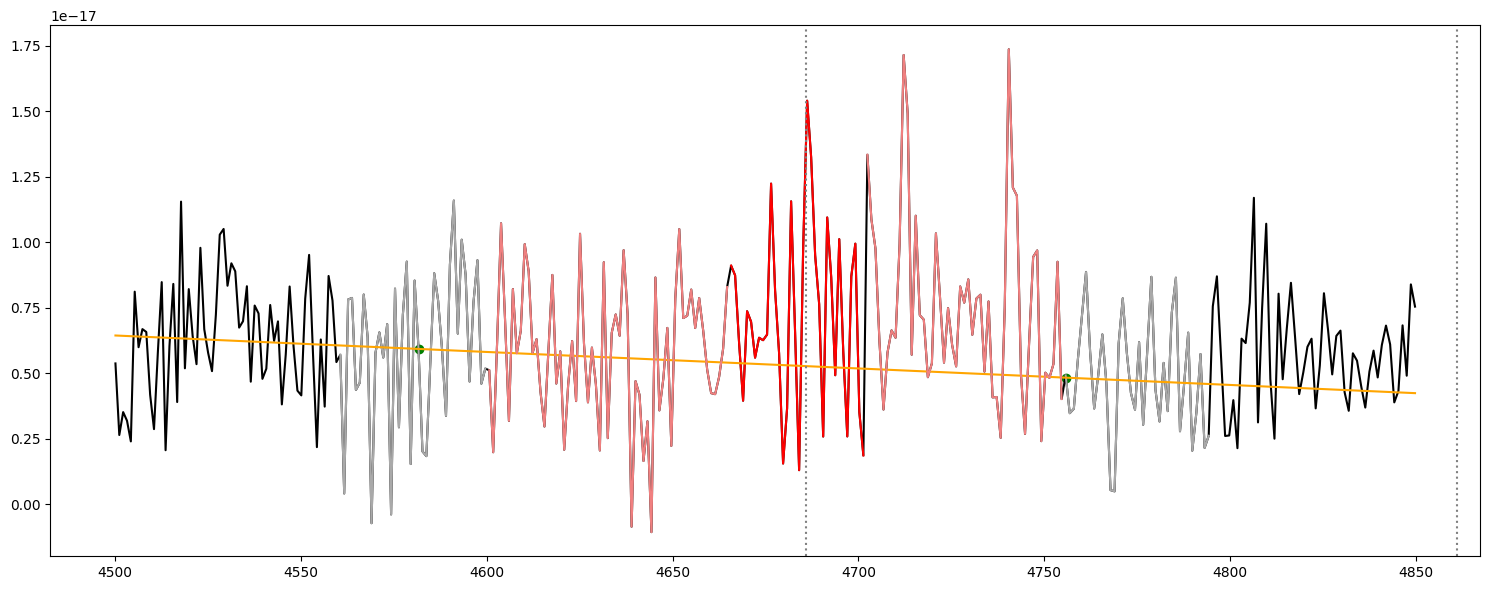

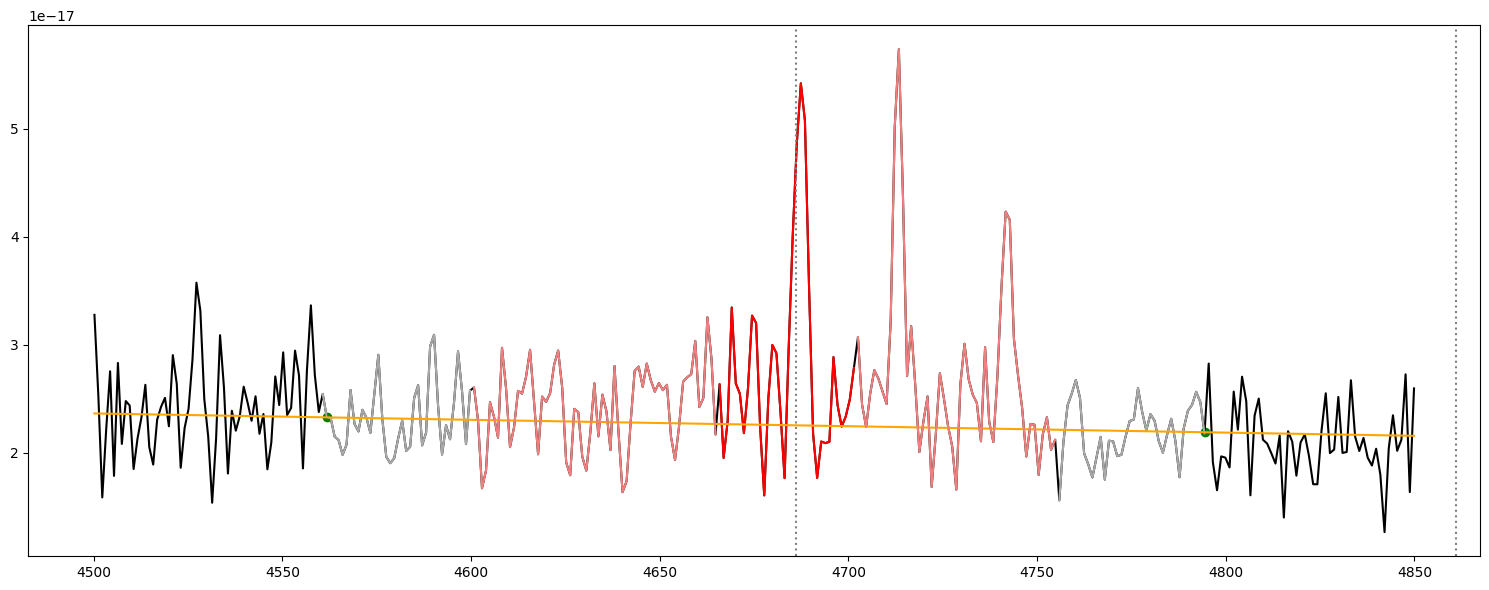

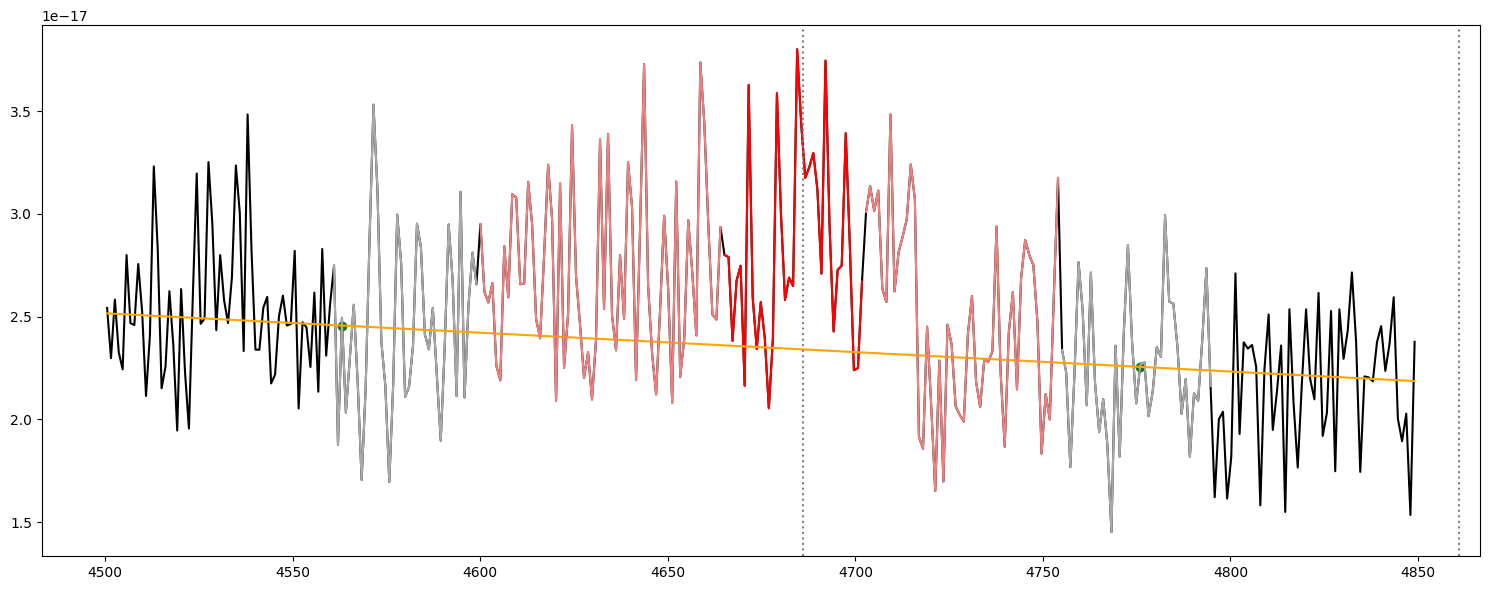

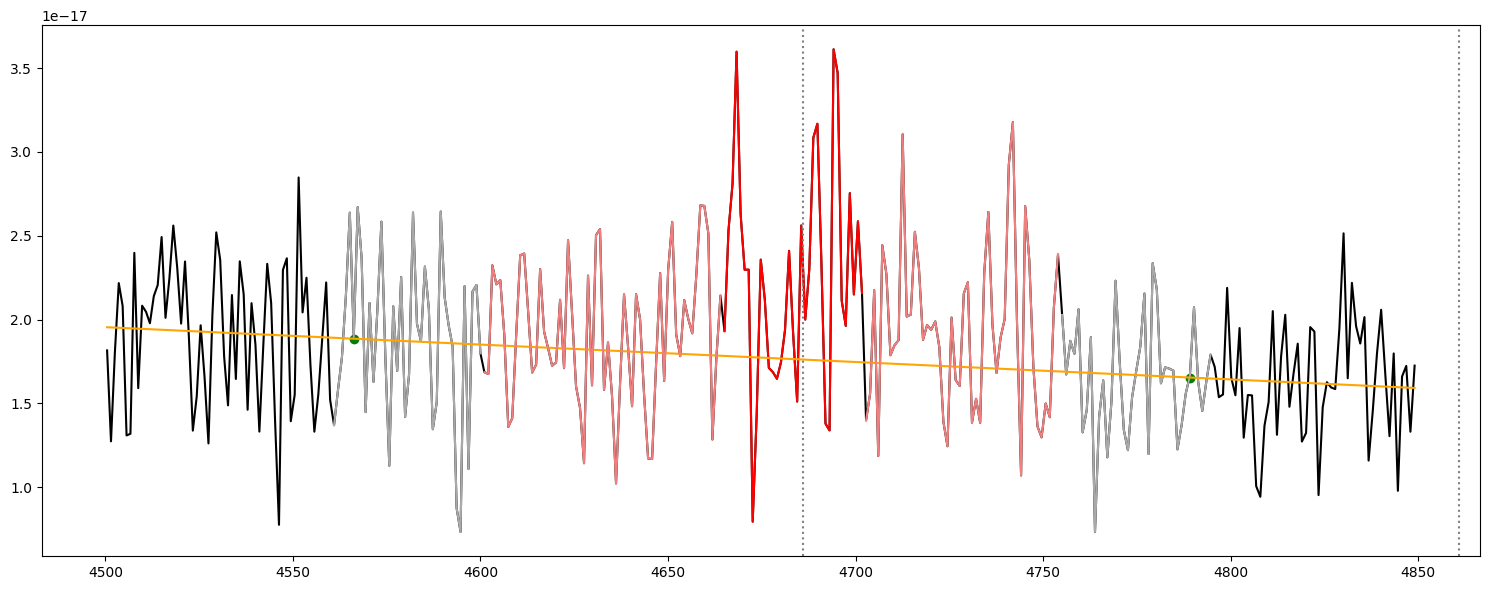

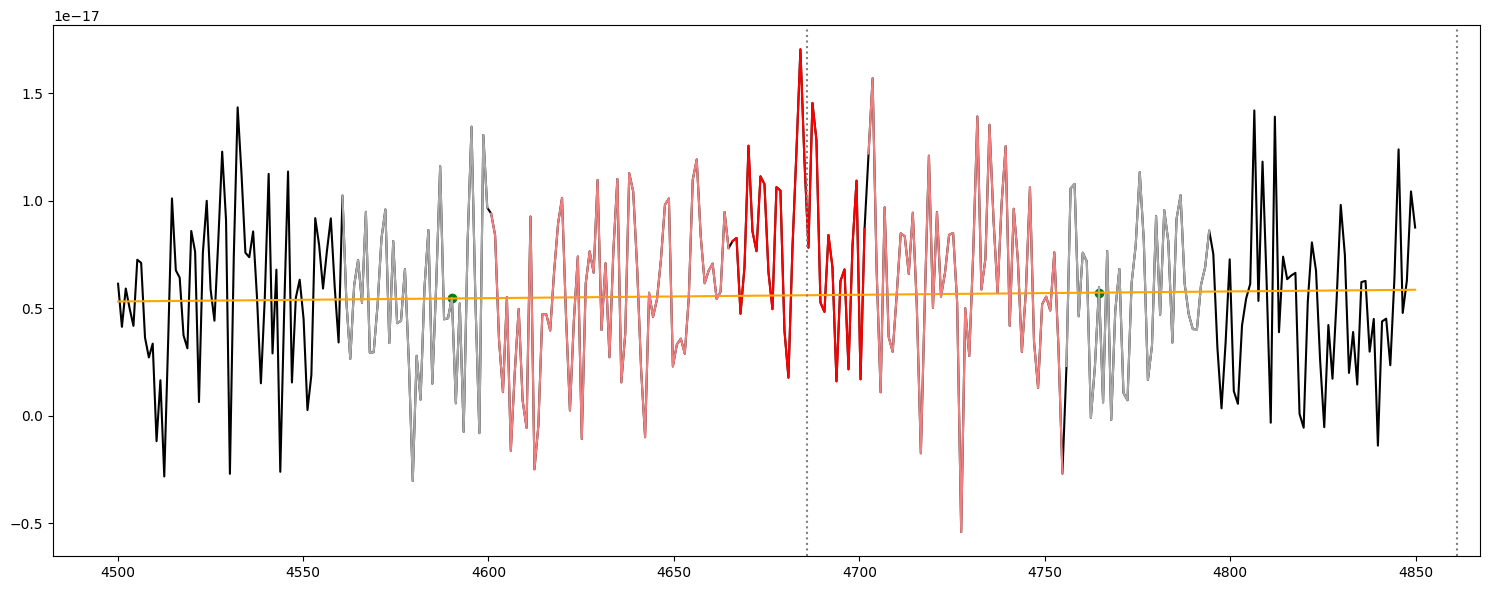

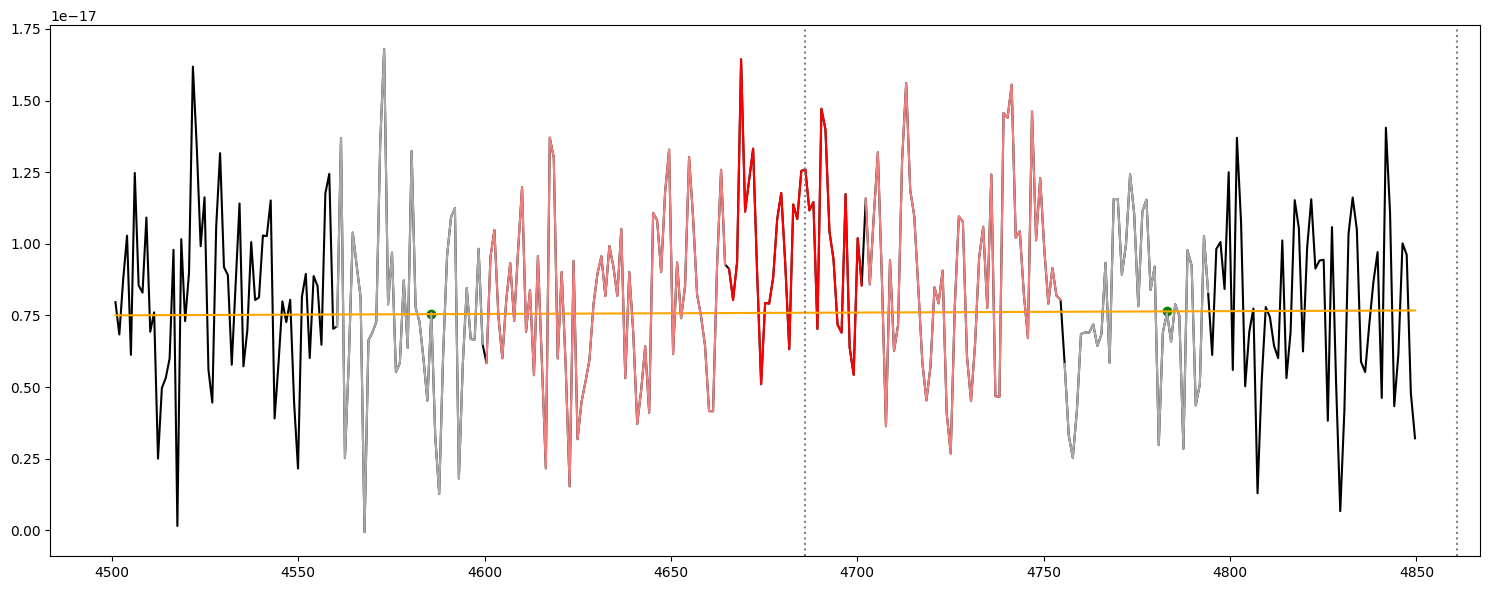

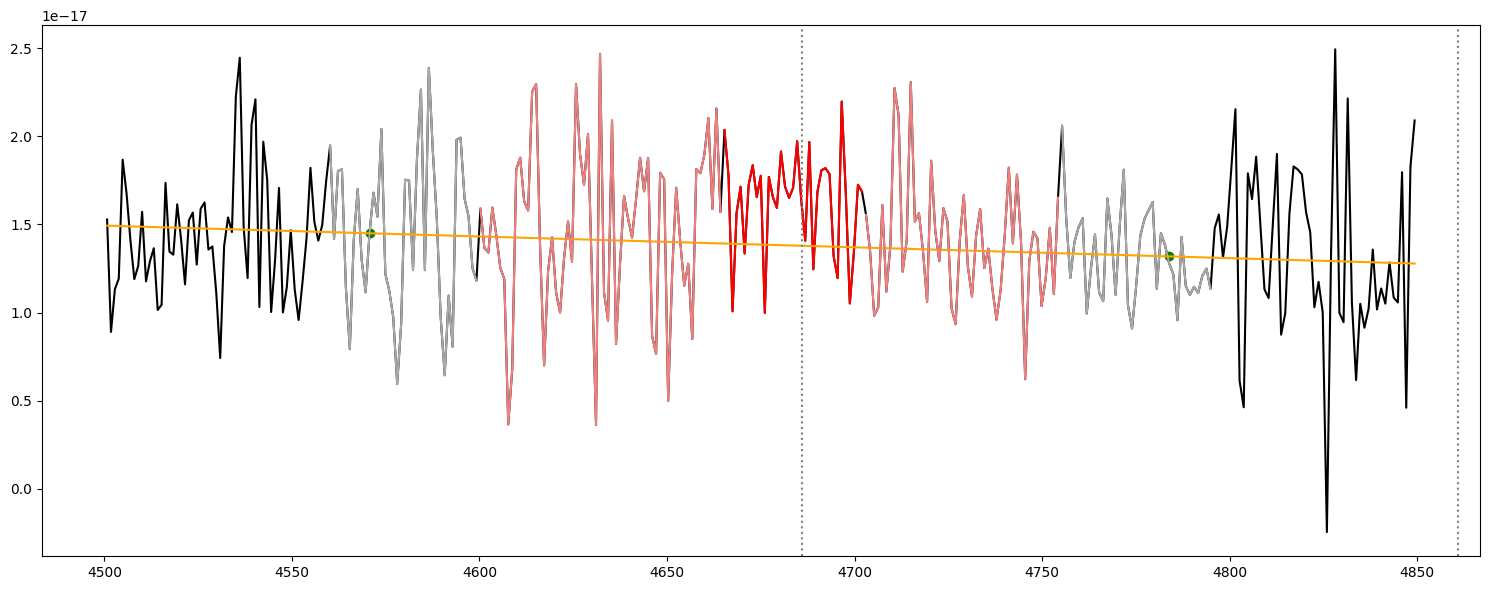

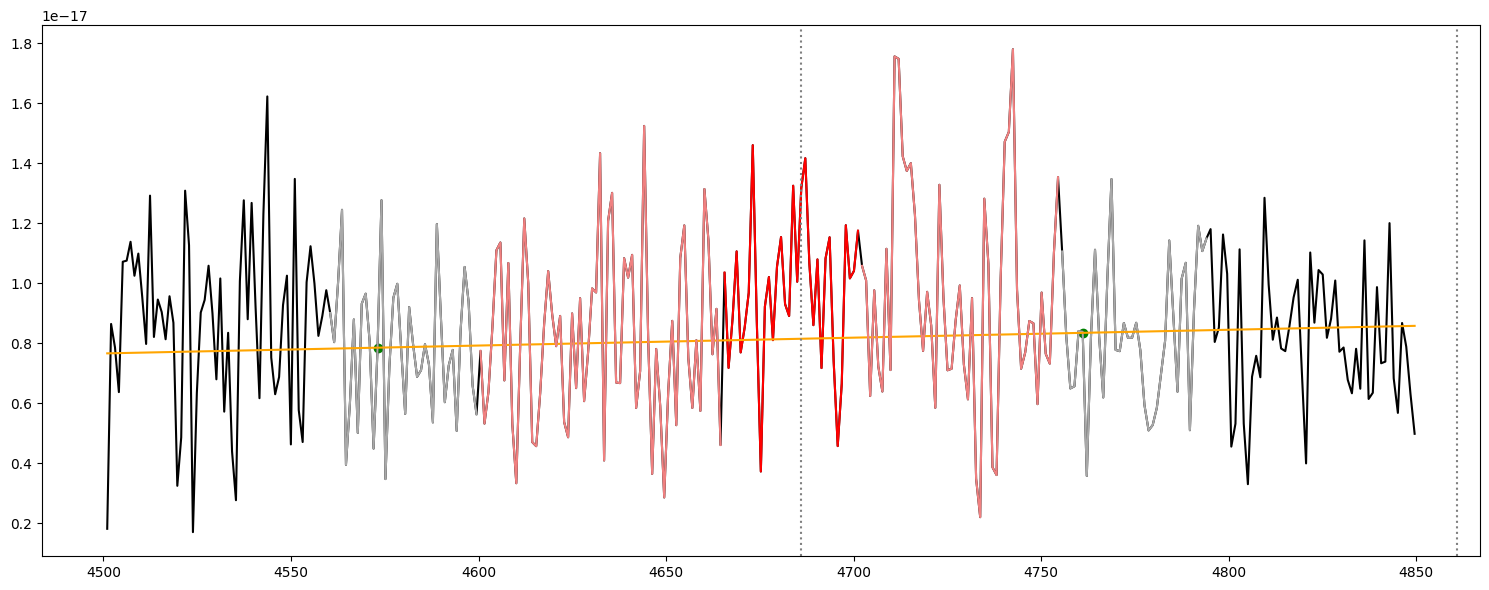

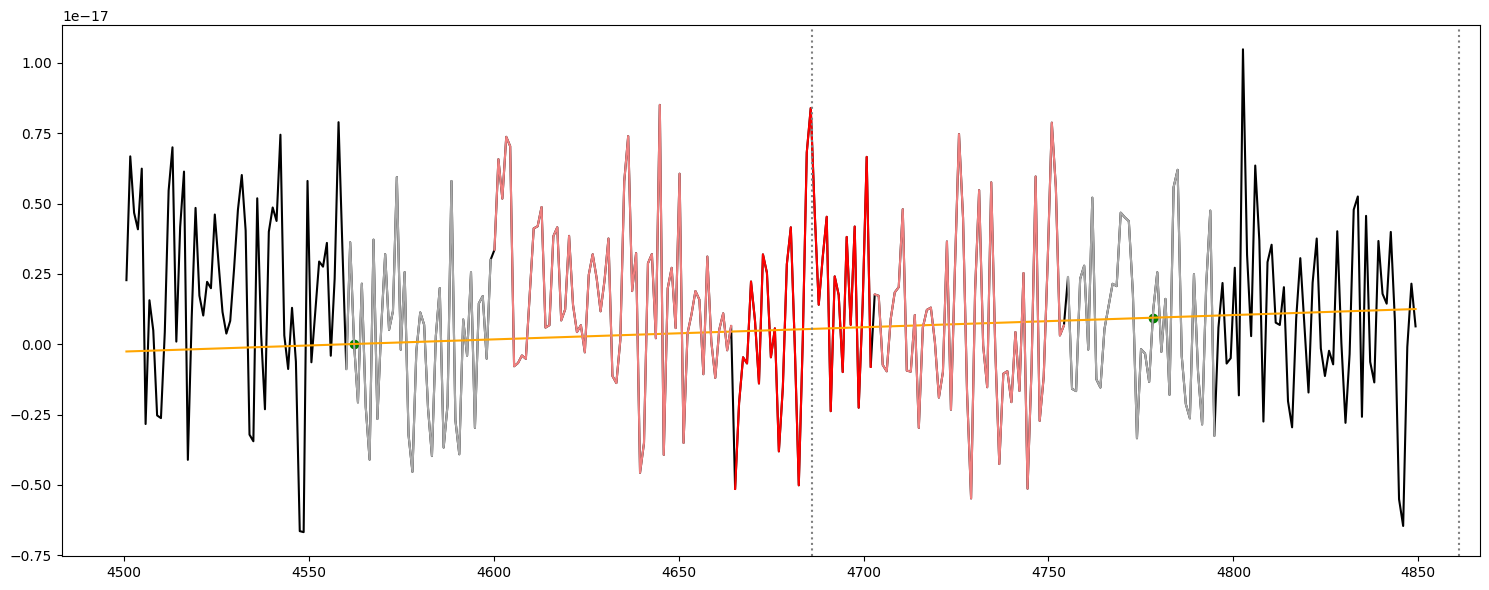

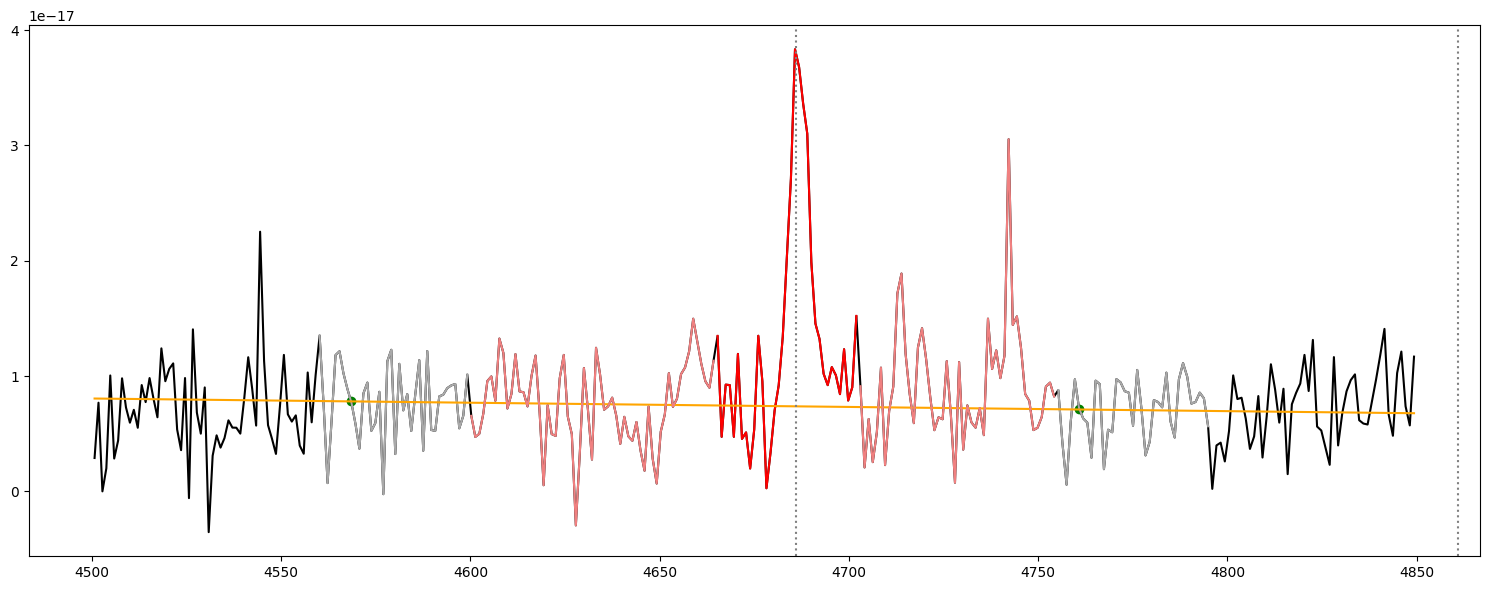

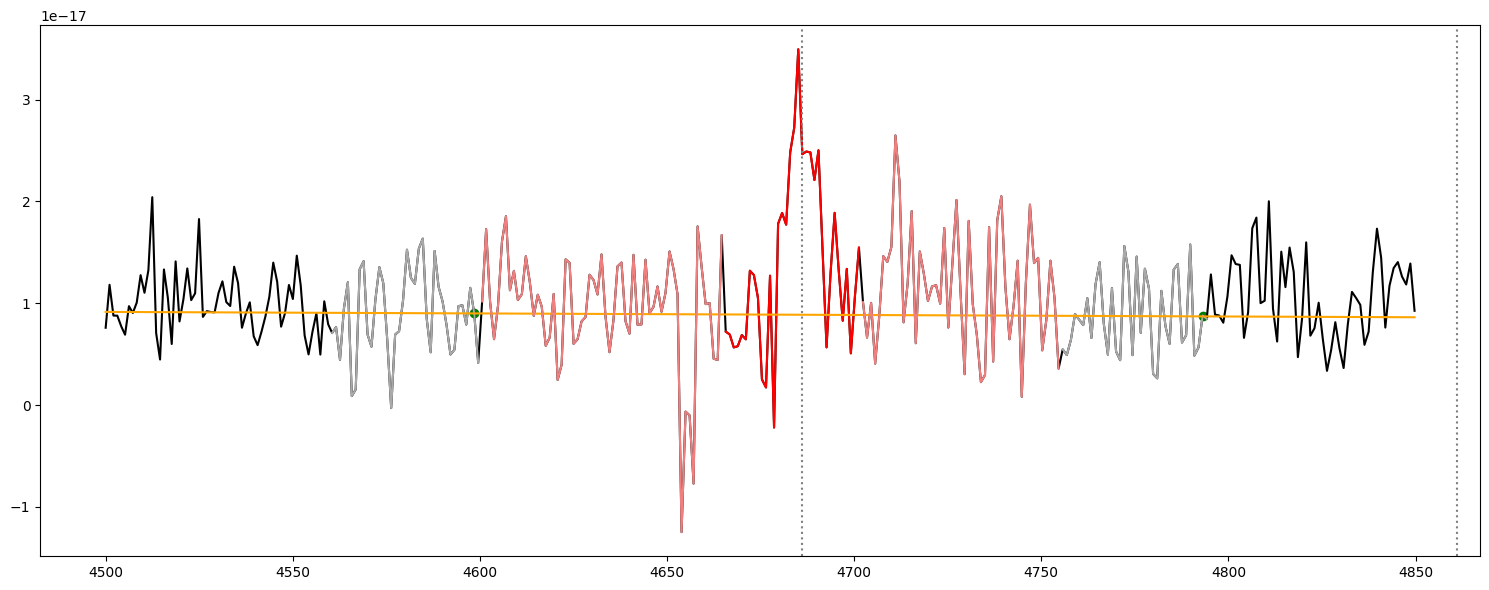

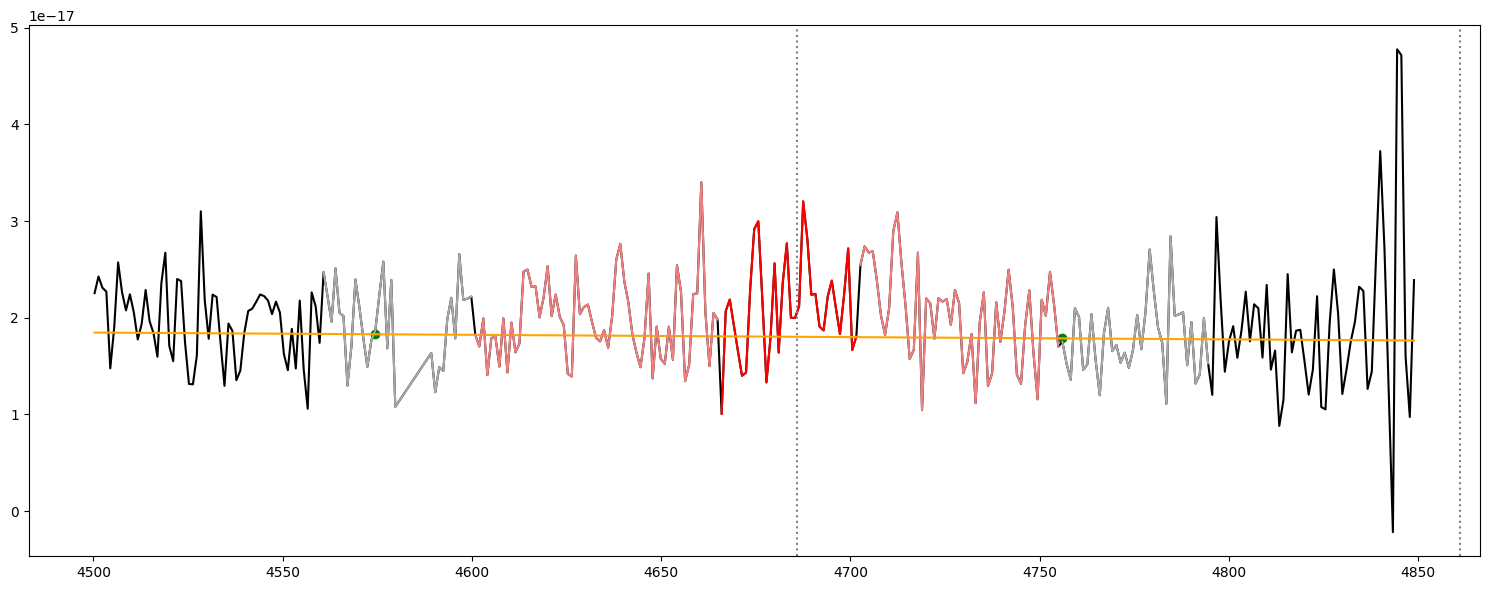

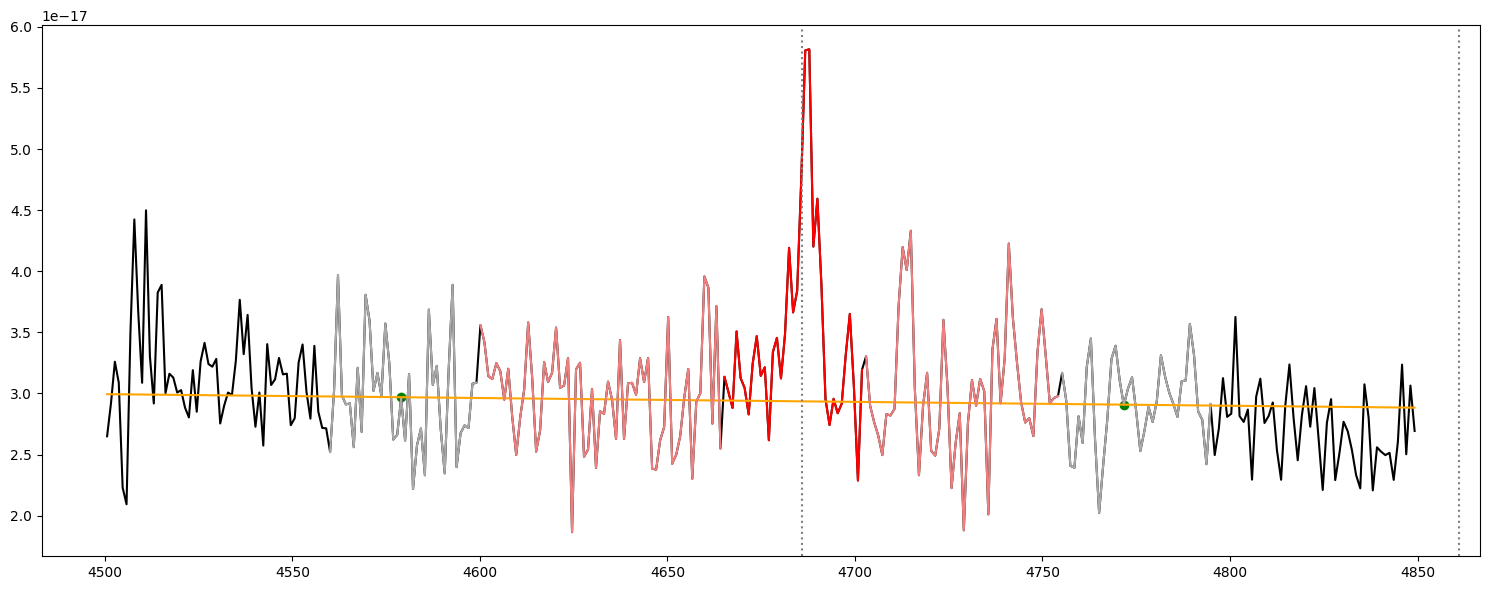

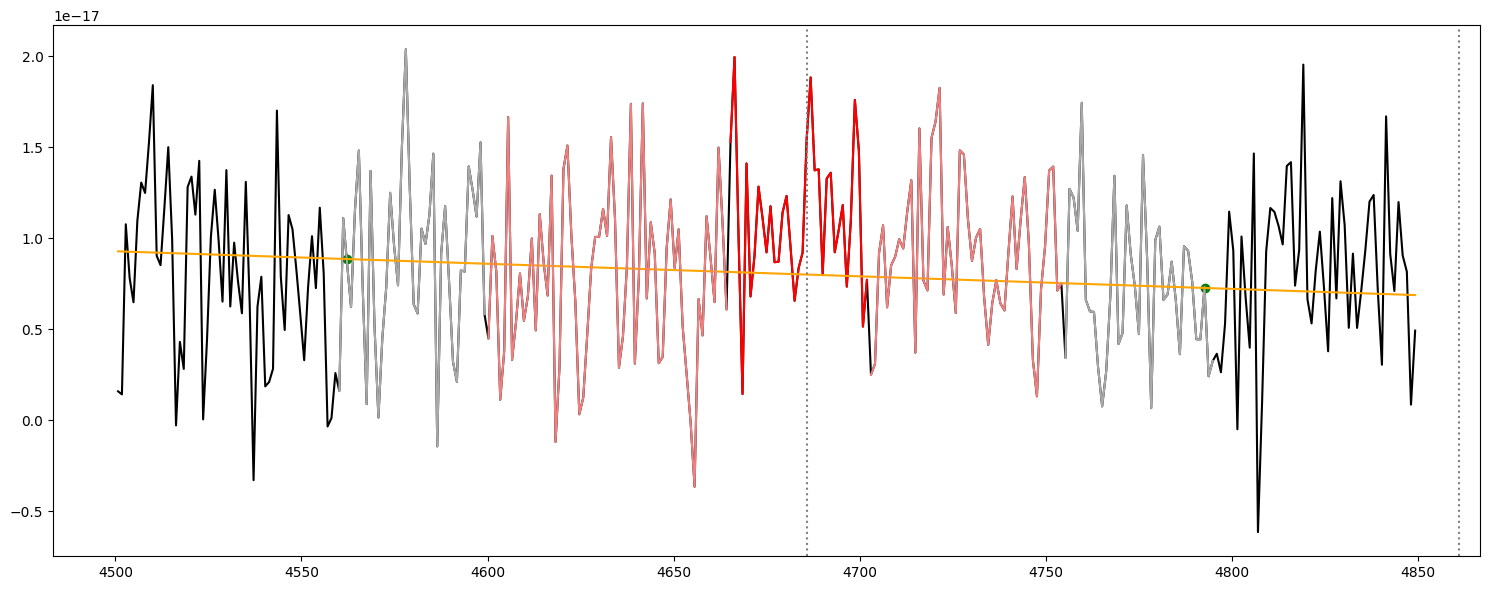

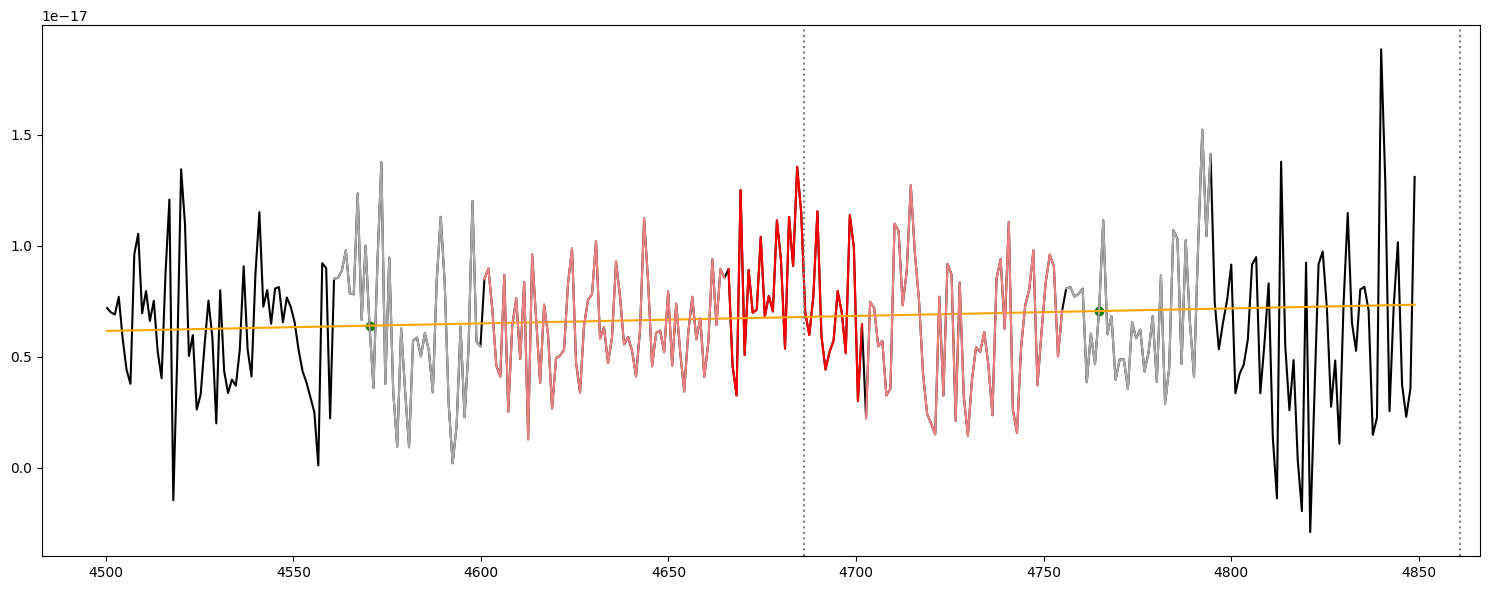

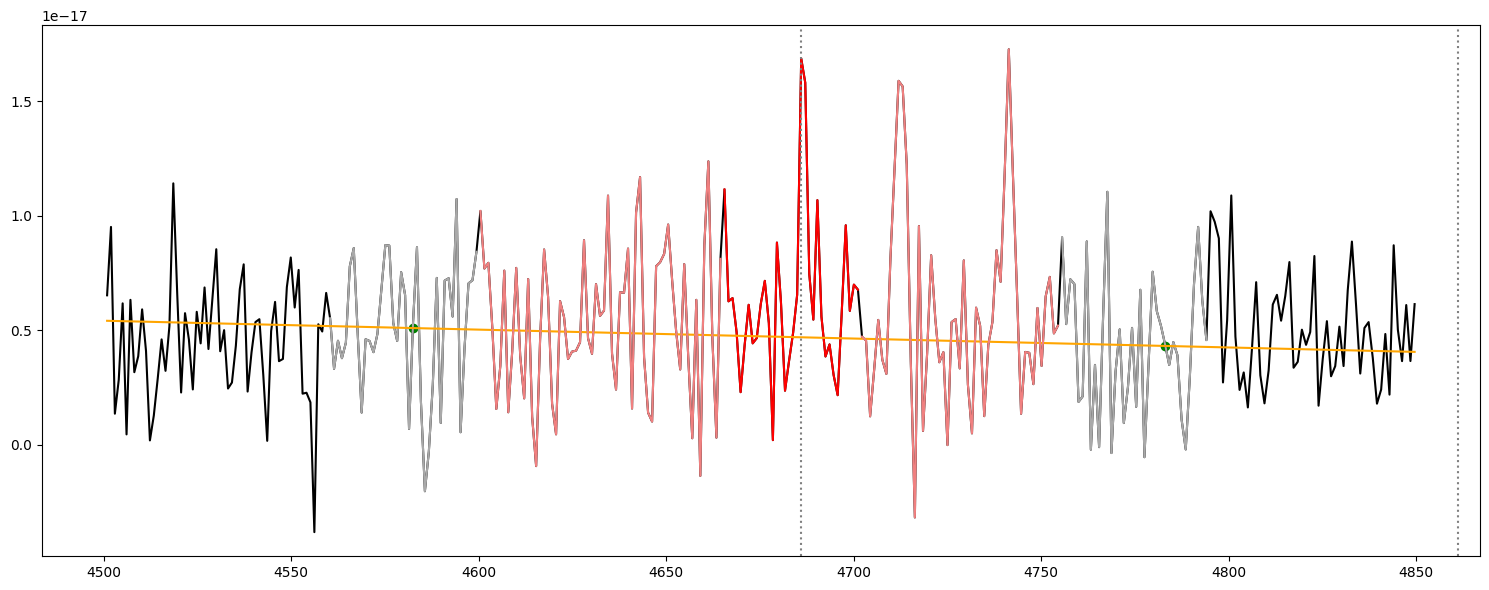

In [50]:
# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# a = 0
# c = 5
# # c = num_filtered - 1
# kay = np.linspace(a, c, ((c-a)+1), dtype=int)

kay = [2, 7, 12, 17, 18, 22, 24, 28, 29, 30, 34, 37, 40, 43, 49, 55, 66, 77]

k = np.array(kay)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

for i in k:            
    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)
    
    x = rest_frame_wavelengths_2[i] ######POTENTIAL TO CHAN
    y = rest_frame_flux_densities_2[i]
    
    ## Median Smooth spectra[po
    ############ Creating axes #################
    highlighted = right_flat[i] | left_flat[i] # "Flat" continuum portions
    
    yblue = rest_frame_flux_densities_2[i].copy()
    yblue[~highlighted] = np.nan
    
    ybump = rest_frame_flux_densities_2[i].copy()
    ybump[~HeII_bump[i]] = np.nan

  
    out_bump = rest_frame_flux_densities_2[i].copy()
    WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
    out_bump[~WolfRayet_bump] = np.nan
 
    yspectra = rest_frame_flux_densities_2[i].copy()
    yspectra[~between[i]] = np.nan

    # baseline = equation.copy()
    baseline = linear_func(x).copy()
    baseline[~between[i]] = np.nan

    plt.figure(figsize=(15,6))

    ############### Plotting ###################
    plt.plot(x, yspectra, color='black')
    plt.plot(x, yblue, color='darkgray')
    plt.plot(x, ybump, color='red')
    plt.plot(x, baseline, color='orange')
    plt.plot(x, out_bump, color ='lightcoral')
    # plt.plot(x, rest_frame_flux_density_errs_2[i])
    plt.scatter(x_points, y_points, color='green')

    plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
    plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')

    #yscale = log
    # plt.yscale('log')
    median_flux = np.median(rest_frame_flux_densities_2[i])
    lower_y_lim = median_flux * 0.005
    upper_y_lim = median_flux * 5
    # plt.ylim(lower_y_lim, upper_y_lim)
    plt.tight_layout() 
    plt.show()


In [ ]:
# saving this initial VMS subsample for future reference
# initial_VMS_eBOSS.to_csv('../subsamples/initial_VMS_eBOSS.csv', index=False)

In [ ]:
Potential: [58, 60, 73, 75, 78, 85, 91, 94]

In [ ]:
wolf-rayet = [2, 7, 12. 17, 18, 22, 24, 28, 29, 30, 34, 37, 40, 43, 49, 55, 66, 77]